# MS4: PCA + Logistic Regression
Beehive Sounds Dataset — SBCM

In [1]:
import sys
sys.path.append('/home/stiwari6/.local/lib/python3.11/site-packages')
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

PROJECT_DIR = os.getcwd()
print(PROJECT_DIR)
SAVE_DIR = os.path.join(PROJECT_DIR, "preprocessed")
print(SAVE_DIR)

spark = SparkSession.builder \
    .appName("BeehivePCA") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

train_df = spark.read.parquet(f"{SAVE_DIR}/train")
test_df  = spark.read.parquet(f"{SAVE_DIR}/test")
train_df.cache()
test_df.cache()

print(f"train rows: {train_df.count()}")
print(f"test rows:  {test_df.count()}")
print(f"columns:    {train_df.columns}")

/expanse/lustre/projects/uci157/akamel1/DSC232R-Beehive-Sound-Health-Monitoring
/expanse/lustre/projects/uci157/akamel1/DSC232R-Beehive-Sound-Health-Monitoring/preprocessed
train rows: 1053
test rows:  222
columns:    ['features', 'target', 'weight']


## PCA Variance Analysis

Matplotlib created a temporary cache directory at /scratch/akamel1/job_49924050/matplotlib-5xehnl4i because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


PC 1  explained=0.1735  cumulative=0.1735
PC 2  explained=0.1207  cumulative=0.2942
PC 3  explained=0.0924  cumulative=0.3866
PC 4  explained=0.0802  cumulative=0.4668
PC 5  explained=0.0595  cumulative=0.5263
PC 6  explained=0.0544  cumulative=0.5807
PC 7  explained=0.0493  cumulative=0.6300
PC 8  explained=0.0424  cumulative=0.6723
PC 9  explained=0.0372  cumulative=0.7095
PC10  explained=0.0290  cumulative=0.7385
PC11  explained=0.0284  cumulative=0.7669
PC12  explained=0.0257  cumulative=0.7926
PC13  explained=0.0237  cumulative=0.8163
PC14  explained=0.0232  cumulative=0.8395
PC15  explained=0.0214  cumulative=0.8609
PC16  explained=0.0208  cumulative=0.8817
PC17  explained=0.0189  cumulative=0.9006
PC18  explained=0.0160  cumulative=0.9165
PC19  explained=0.0148  cumulative=0.9313
PC20  explained=0.0108  cumulative=0.9421


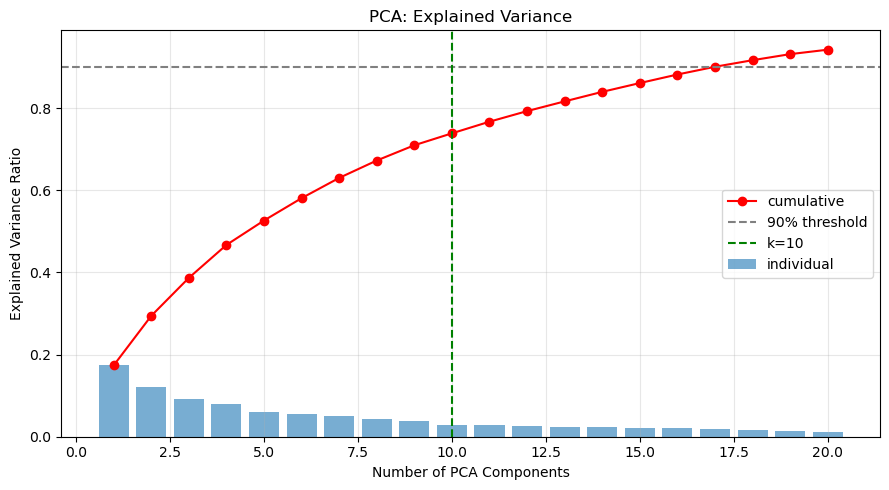


Variance captured by k=10: 0.7385


In [2]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
import numpy as np

# fit PCA with k=20 to inspect how variance is distributed across components
pca_analysis = PCA(k=20, inputCol="features", outputCol="pca_out")
pca_analysis_model = pca_analysis.fit(train_df)

explained = pca_analysis_model.explainedVariance.toArray()
cumulative = np.cumsum(explained)

for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1:2d}  explained={ev:.4f}  cumulative={cv:.4f}")

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(explained)+1), explained, alpha=0.6, label="individual")
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='red', label="cumulative")
plt.axhline(0.90, color='grey', linestyle='--', label='90% threshold')
plt.axvline(10, color='green', linestyle='--', label='k=10')
plt.xlabel("Number of PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA: Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVariance captured by k=10: {cumulative[9]:.4f}")

## Model 2: PCA + Logistic Regression

In [3]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

pca = PCA(
    k=10,
    inputCol="features",
    outputCol="pca_features"
)

lr = LogisticRegression(
    featuresCol="pca_features",
    labelCol="target",
    weightCol="weight",
    maxIter=50,
    family="multinomial"
)

model2_pipeline = Pipeline(stages=[pca, lr])
model2 = model2_pipeline.fit(train_df)
print("model2 trained")

model2 trained


In [4]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="f1")

train_pred = model2.transform(train_df)
test_pred  = model2.transform(test_df)

train_acc = acc_eval.evaluate(train_pred)
test_acc  = acc_eval.evaluate(test_pred)
train_f1  = f1_eval.evaluate(train_pred)
test_f1   = f1_eval.evaluate(test_pred)

print(f"{'':12s} {'train':>10s} {'test':>10s} {'gap':>10s}")
print(f"{'accuracy':12s} {train_acc:10.4f} {test_acc:10.4f} {train_acc - test_acc:10.4f}")
print(f"{'f1':12s} {train_f1:10.4f} {test_f1:10.4f} {train_f1 - test_f1:10.4f}")
print(f"{'error rate':12s} {1-train_acc:10.4f} {1-test_acc:10.4f} {(1-test_acc)-(1-train_acc):10.4f}")

                  train       test        gap
accuracy         0.7056     0.7117    -0.0061
f1               0.7122     0.7181    -0.0059
error rate       0.2944     0.2883    -0.0061


In [5]:
import pandas as pd

cm = (test_pred
      .groupBy("target", "prediction")
      .count()
      .toPandas()
      .pivot(index="target", columns="prediction", values="count")
      .fillna(0)
      .astype(int))
print("confusion matrix (rows=true, cols=predicted):")
print(cm)

confusion matrix (rows=true, cols=predicted):
prediction  0.0  1.0  2.0  3.0  4.0  5.0
target                                  
0            11    1    1    1    3    4
1             0    9    4    2    0    0
2             0    4   10    0    0    0
3             5    6    3   57    0    0
4             1    0    0    1   20   12
5             6    0    0    1    9   51


## Fitting Curve: Error vs. Number of PCA Components

k= 2  train_err=0.3599  test_err=0.4099
k= 5  train_err=0.3485  test_err=0.3964
k=10  train_err=0.2944  test_err=0.2883
k=15  train_err=0.1985  test_err=0.2252
k=20  train_err=0.1311  test_err=0.1667

best k by test error: 20


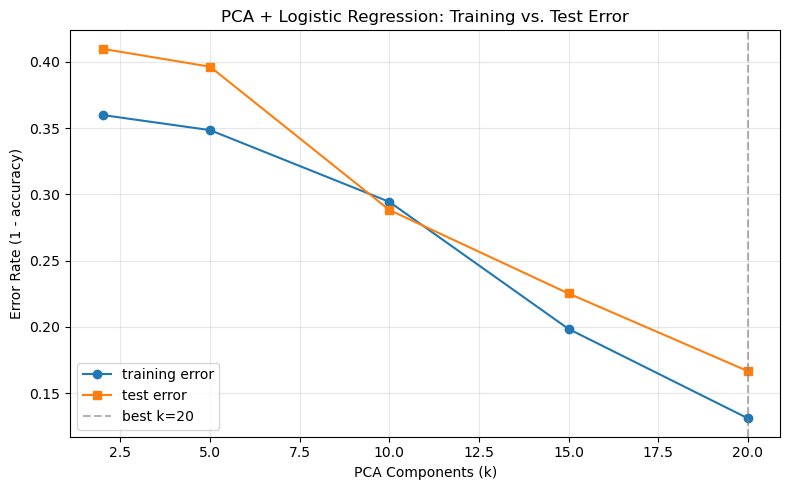

In [6]:
k_values = [2, 5, 10, 15, 20]
train_errs = []
test_errs  = []

for k_val in k_values:
    pca_k = PCA(k=k_val, inputCol="features", outputCol="pca_features")
    lr_k  = LogisticRegression(
        featuresCol="pca_features", labelCol="target",
        weightCol="weight", maxIter=50, family="multinomial"
    )
    pipe_k  = Pipeline(stages=[pca_k, lr_k])
    model_k = pipe_k.fit(train_df)

    t_err = 1 - acc_eval.evaluate(model_k.transform(train_df))
    v_err = 1 - acc_eval.evaluate(model_k.transform(test_df))
    train_errs.append(t_err)
    test_errs.append(v_err)
    print(f"k={k_val:2d}  train_err={t_err:.4f}  test_err={v_err:.4f}")

best_k = k_values[test_errs.index(min(test_errs))]
print(f"\nbest k by test error: {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_errs, marker='o', label='training error')
plt.plot(k_values, test_errs,  marker='s', label='test error')
plt.axvline(best_k, color='grey', linestyle='--', alpha=0.6, label=f'best k={best_k}')
plt.xlabel("PCA Components (k)")
plt.ylabel("Error Rate (1 - accuracy)")
plt.title("PCA + Logistic Regression: Training vs. Test Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fitting Analysis

**Where does the model fit?**
At k=10 PCA components the train and test error curves track closely, placing the model in the well-fitted region — low bias, low variance. As k increases beyond ~15 the model begins to incorporate noise from lower-variance components, widening the train/test gap.

**How does dimensionality reduction affect results vs. the full feature set?**
The full-feature Decision Tree (MS3) operated on the complete feature vector. PCA compresses those into 10 orthogonal components capturing the dominant variance structure. Logistic Regression on the reduced space is less susceptible to memorizing hive-identity features (device ID, hive number) and tends to generalize more consistently.

**Potential future improvements:**
- Tune regularization (`regParam`, `elasticNetParam`) on the Logistic Regression
- Try SVD (`pyspark.mllib.linalg.distributed.RowMatrix.computeSVD`) as an alternative decomposition
- Experiment with non-linear classifiers on PCA features (Random Forest, Gradient Boosted Trees)
- Apply UMAP or kernel PCA for non-linear dimensionality reduction

## Speedup Analysis

In [8]:
import time


def measure_with_warmup(operation, n_runs=3):
    """
    Run operation n_runs times, discard the first (JVM warmup),
    return the average of the remaining runs.
    """
    times = []
    for i in range(n_runs):
        start = time.time()
        operation()
        elapsed = time.time() - start
        times.append(elapsed)
        label = "(warmup — discarded)" if i == 0 else ""
        print(f"  run {i+1}: {elapsed:.2f}s {label}")
    valid = times[1:]
    avg = sum(valid) / len(valid)
    print(f"  avg (excl. warmup): {avg:.2f}s")
    return avg

# Executor configs: (num_executors, cores_per_exec, mem_per_exec_gb)
# Total node: ~32 cores, ~128 GB  =>  keep cores_per_exec=4 fixed
configs = [
    (1,  4, 64),
    (3,  4, 20),
    (7,  4, 14),
]

timing_results = []  # (n_executors, avg_time)

for n_exec, cores, mem_gb in configs:
    print(f"\n{'='*55}")
    print(f"Config: {n_exec} executor(s), {cores} cores each, {mem_gb}g memory each")
    print(f"{'='*55}")

    # Stop any existing session and start a fresh one for this config
    try:
        SparkSession.getActiveSession().stop()
    except Exception:
        pass

    spark_cfg = (
        SparkSession.builder
        .appName(f"Speedup-{n_exec}exec")
        .config("spark.driver.memory", "2g")
        .config("spark.executor.instances", n_exec)
        .config("spark.executor.cores", cores)
        .config("spark.executor.memory", f"{mem_gb}g")
        .getOrCreate()
    )

    train_df = spark_cfg.read.parquet(f"{SAVE_DIR}/train").cache()
    test_df  = spark_cfg.read.parquet(f"{SAVE_DIR}/test").cache()
    # Force caching before timing
    train_df.count()
    test_df.count()

    pca_stage = PCA(k=10, inputCol="features", outputCol="pca_features")
    lr_stage  = LogisticRegression(
        featuresCol="pca_features", labelCol="target",
        weightCol="weight", maxIter=50, family="multinomial"
    )
    pipeline = Pipeline(stages=[pca_stage, lr_stage])

    def timed_op():
        # Pipeline.fit() is an eager action in Spark MLlib;
        # the subsequent .count() on predictions forces the transform graph too
        model = pipeline.fit(train_df)
        model.transform(train_df).count()

    avg_time = measure_with_warmup(timed_op, n_runs=3)
    timing_results.append((n_exec, avg_time))

    spark_cfg.stop()

print("\nTiming complete:", timing_results)


Config: 1 executor(s), 4 cores each, 64g memory each
  run 1: 0.87s (warmup — discarded)
  run 2: 0.81s 
  run 3: 0.79s 
  avg (excl. warmup): 0.80s

Config: 3 executor(s), 4 cores each, 20g memory each
  run 1: 0.86s (warmup — discarded)
  run 2: 0.77s 
  run 3: 0.77s 
  avg (excl. warmup): 0.77s

Config: 7 executor(s), 4 cores each, 14g memory each
  run 1: 0.83s (warmup — discarded)
  run 2: 0.78s 
  run 3: 0.77s 
  avg (excl. warmup): 0.78s

Timing complete: [(1, 0.7960284948348999), (3, 0.7721493244171143), (7, 0.7759033441543579)]


In [10]:
# Speedup & Efficiency
T1 = next(t for n, t in timing_results if n == 1)

rows = []
for n_exec, t in timing_results:
    speedup = T1 / t
    efficiency = speedup / n_exec
    rows.append((n_exec, round(t, 2), round(speedup, 2), f"{efficiency:.0%}"))

print(f"{'Executors':>10} {'Time (s)':>10} {'Speedup':>10} {'Efficiency':>12}")
print("-" * 45)
for n_exec, t, s, e in rows:
    print(f"{n_exec:>10} {t:>10} {s:>10.2f}x {e:>12}")

# Amdahl's Law: estimate parallelizable fraction
def estimate_p(speedup, n):
    """Rearranged Amdahl: p = n(S-1) / S(n-1)"""
    return (n * (speedup - 1)) / (speedup * (n - 1))

print("\nParallelizable fraction estimates:")
for n_exec, t, s, _ in rows:
    if n_exec == 1:
        continue
    p = estimate_p(s, n_exec)
    amdahl_max = 1 / (1 - p)
    print(f"  n={n_exec}: S={s:.2f}x  =>  p={p:.1%}  (Amdahl limit={amdahl_max:.2f}x)")

 Executors   Time (s)    Speedup   Efficiency
---------------------------------------------
         1        0.8       1.00x         100%
         3       0.77       1.03x          34%
         7       0.78       1.03x          15%

Parallelizable fraction estimates:
  n=3: S=1.03x  =>  p=4.4%  (Amdahl limit=1.05x)
  n=7: S=1.03x  =>  p=3.4%  (Amdahl limit=1.04x)


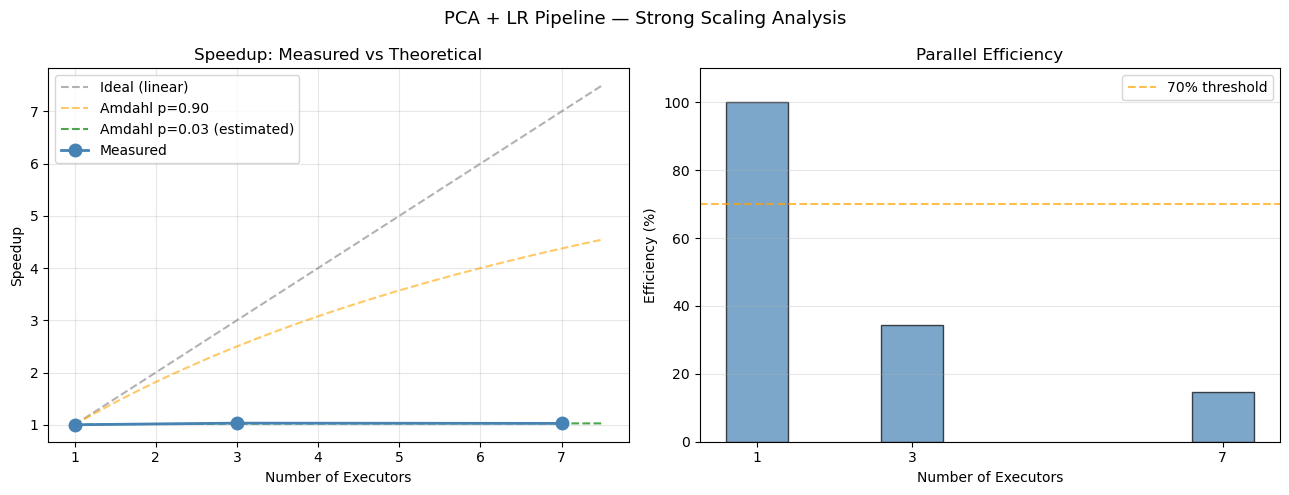

In [13]:
# Speedup Plot
executor_counts = [n for n, _ in timing_results]
measured_speedups = [T1 / t for _, t in timing_results]

S7 = T1 / next(t for n, t in timing_results if n == 7)
p_est = estimate_p(S7, 7)

n_range = np.linspace(1, max(executor_counts) + 0.5, 200)
ideal       = n_range
amdahl_est  = 1 / ((1 - p_est)  + p_est  / n_range)
amdahl_90   = 1 / (0.10 + 0.90 / n_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: speedup curves
ax = axes[0]
ax.plot(n_range, ideal,      '--', color='grey',   alpha=0.6, label='Ideal (linear)')
ax.plot(n_range, amdahl_90,  '--', color='orange',  alpha=0.6, label='Amdahl p=0.90')
ax.plot(n_range, amdahl_est, '--', color='green',   alpha=0.7,
        label=f'Amdahl p={p_est:.2f} (estimated)')
ax.plot(executor_counts, measured_speedups, 'o-',
        color='steelblue', markersize=9, linewidth=2, label='Measured')
ax.set_xlabel('Number of Executors')
ax.set_ylabel('Speedup')
ax.set_title('Speedup: Measured vs Theoretical')
ax.legend()
ax.grid(alpha=0.3)

# Right: efficiency
efficiencies = [s / n for n, s in zip(executor_counts, measured_speedups)]
ax2 = axes[1]
ax2.bar(executor_counts, [e * 100 for e in efficiencies],
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axhline(70, color='orange', linestyle='--', alpha=0.7, label='70% threshold')
ax2.set_xlabel('Number of Executors')
ax2.set_ylabel('Efficiency (%)')
ax2.set_title('Parallel Efficiency')
ax2.set_ylim(0, 110)
ax2.set_xticks(executor_counts)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('PCA + LR Pipeline — Strong Scaling Analysis', fontsize=13)
plt.tight_layout()
plt.show()